<a href="https://colab.research.google.com/github/ikeyareinaldosae/ITC501---Artificial-Intelligence-Applications/blob/main/Weekly%20Labs/Week_6_Image_Classification_with_Tensorflow_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 6 Lab - Image Classification with TensorFlow**

## Introduction

In this lab, we will see how we can **build our own Network** (a Convolutional Neural Network (CNN), a type of neural network designed for image recognition) for processing images **Keras API from TensorFlow**.

By the end of this lab, you will be able to:

*   Import the relevant classes from TensorFlow and Keras
*   Design the architecture of a custom Convolutional Neural Network (CNN)
*   Fit (train) a CNN model and evaluate its performance
*   Make predictions using the trained model
*   Compute and interpret performance metrics
*   Generate and analyze a classification report
*   Create and visualize a confusion matrix to assess model performance















## **Predicting Hand-Written Digits (multi-class classification)**

### Dataset

The dataset we will be using is **MNIST** - a famous **dataset** used in machine learning and computer vision for **handwritten digit recognitio**n.

The data was originally published by Hans Hofmann from the Institute of Statistics and Econometrics at Universität Hamburg, Faculty of Economics and Social Sciences, located in Hamburg, Germany.

Each observation is a **black and white image** of **size 28 by 28** representing a **single hand-written digit**.

This dataset is avalaible from Tensorflow: [MNIST](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist)

### Objective

Our goal is to build a Convolution Neural Network model that can accurately predict the hand-written digit from an image.

### Instructions

This is a guided exercise where some of the code have already been pre-defined. Your task is to fill the remaining part of the code (it will be highlighted with placehoders) to train and evaluate your model.

This exercise is split in several parts:

1. Loading and Exploration of the Dataset
2. Preparing the Dataset
3. Defining the CNN Architecture:

    - Convolutional layer with 128 kernels of (3,3)
    - Max pooling of (2,2)
    - Convolutional layer with 64 kernels of (3,3)
    - Max pooling of (2,2)
    - Flatten Layer
    - Fully-connected layer of 128 units
    - Fully-connected layer of 10 units
    - ReLU as the activation function for the hidden layers
    - Adam as the optimiser

4.   Training and Evaluation of the Model
5.   Analysing the Results

## **Exercise 1**

### 1. Loading and Exploration of the Dataset

**[1.1]**
First we need to import the relevant class that contains the dataset from TensorFlow

##### **Task: Load the MNIST dataset from TensorFlow**

In [4]:
# Placeholder for student's code (1 line of code)
# Task: Load the MNIST dataset
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model

**[1.2]**
Then we will load the dataset using the [`.load_data()`](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/boston_housing/load_data) method

**Note:** The dataset from Tensorflow has already been split into training and testing sets. The output is 2 tuples each containing the features and target variable as numpy arrays for the training and testing sets.

##### **Task: Load the dataset into 4 different variables (`X_train`, `y_train`, `X_test`, `y_test`)**

In [5]:
# Task: Load the dataset into 4 different variables (X_train, y_train, X_test, y_test)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**[1.3]** Look at the dimensions of X_train and X_test numpy arrays using the [`.shape()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.shape.html) method


##### **Task: Display the dimensions of `X_train` and `X_test`**

In [6]:
# Task: Display the dimensions of X_train and X_test
# Check shapes of the datasets
print(f"x_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)



**[1.4]** Review the first 5 images from the `X_train` dataset.

This part is completed for you, so you can see the images. However, you are encouraged to change the indices in the `for` loop, and review some of the other images yourself.

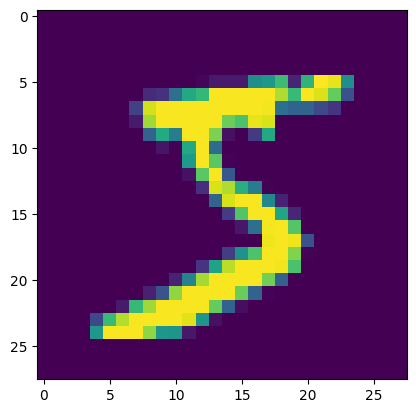

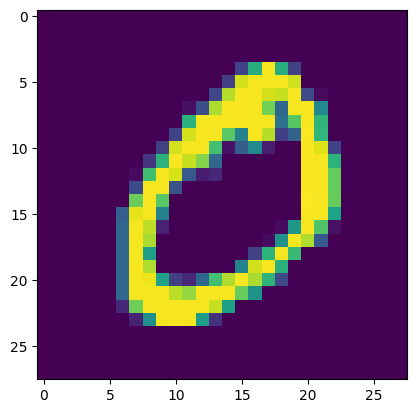

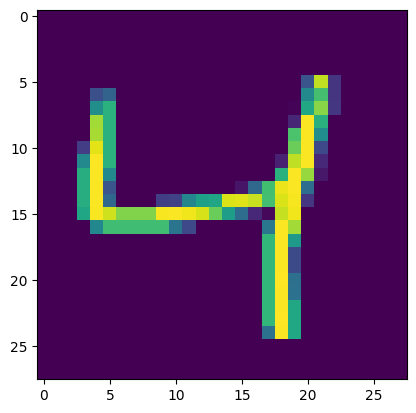

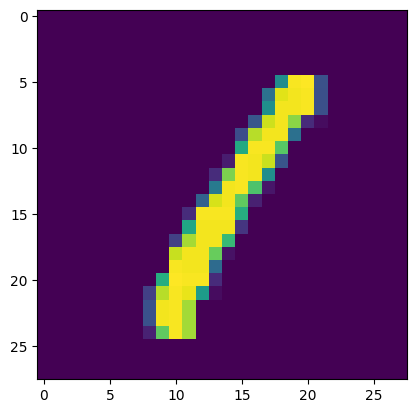

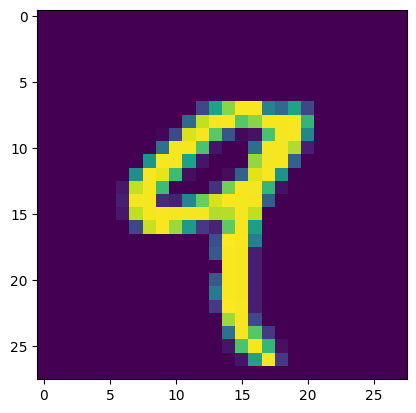

In [7]:
from matplotlib import pyplot as plt

for image in X_train[:5]:
    plt.imshow(image)
    plt.show()

### **2.   Preparing the Dataset**

**[2.1]** We will need to normalise both the features for the training and testing sets.

**Note:** An image is composed of pixels with values from `0` to `255`. We can therefore normalize it by dividing its pixels by the maximum value (ie `255`). All pixel values will be then ranging from `0` to `1`.

##### **Task: Normalize the training and testing sets by dividing them by `255`**

In [8]:
# Task: Normalize the training and testing sets by dividing them by 255
# .astype("float32") explicitly converts the data type to float32 and ensures compatibility with TensorFlow, which typically uses float32.
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

**[2.2]** A CNN model is expecting inputs of the following dimensions: (width, height, channel). The MNIST dataset is composed of grayscale images so it has only 1 channel. We will need to reshape the images to add this color channel using [`.reshape()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.reshape.html) method from numpy.

In [9]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1) #X_train.shape[0] returns the number of samples (images) in the training dataset.
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)    #X_test.shape[0] returns the number of samples (images) in the testing dataset.

### **3.   Defining the Architecture of CNN**

**[3.1]** First we need to import tensorflow, numpy and the Keras layers

In [10]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Conv2D,
    Dense,
    MaxPooling2D,
    Flatten,
)

**[3.2]** Then we will set the seeds for tensorflow and numpy in order to get reproducible results

In [11]:
# random seed for TensorFlow and NumPy so that your results are more reproducible.
tf.random.set_seed(168)
np.random.seed(168)

**[3.3]** First we will create a [`Sequential()`](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential) class

In [12]:
#A Sequential model is a neural network where the layers are arranged one after another in a single sequence.
#The output of one layer becomes the input to the next.

model = Sequential() #This line creates an empty Sequential model in Keras.

**[3.4]** Let's create 2 convolutional layers using the [`Conv2D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D) class from Keras

##### **Task: Create 2 convolutional layers with the right number of kernels, size of kernel and activation function.**

Note:

- The first layer will need to have `128` filters, with a kernel size of `(3, 3)`, an input shape of `(28, 28, 1)` (which is the same as the input image size), and the `relu` activation function.
- The second layer will need to have `64` filters, with a kernel_size if `(3, 3)`, and the `relu` activation function.

In [13]:
# Placeholder for student's code (2 lines of code)
# Task: Task: Create 2 convolutional layers with the right number of kernels, size of kernel and activation function.
conv_layer1 = Conv2D(128,(3,3),input_shape=(28,28,1), activation = "relu")
conv_layer2 = Conv2D(64,(3,3), activation = "relu")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**[3.5]** Now we will instantiate 2 fully-connected layers for making the predictions by using the [`Dense()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) class.

##### **Task: Create 2 fully-connected and specify the right number of units and activation function**

Note:

- The first layer will need to have `128` units, and uses the `relu` activation function
- The second layer will need to have `10` units (which is the total number of possible outcomes from the MNIST data, being 10 numbers from 0 to 9), and an activation function of `softmax`.

In [14]:
# Placeholder for student's code (2 lines of code)
# Task: Create 2 fully-connected and specify the right number of units and activation function
fc_layer1 = Dense(128,activation = "relu")
fc_layer2 = Dense(10,activation = "softmax")

**[3.6]** We will also instantiate a Max Pooling layer with [`MaxPooling2D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D) that will be used after each Conv2D

A Flatten layer is also required to bridge the gap between convolutional layers (which operate on multi-dimensional data) and fully connected layers (which require 1D data). Flatten layer allows the transition from spatially structured data to a flattened representation that can be processed by densely connected layers.

In [15]:
max_pool = MaxPooling2D(2, 2)
flatten = Flatten()

**[3.7]** Now it is time to combine all the layers we defined into our model.

##### **Task: Add the layers to form our CNN model**

In [16]:
# Placeholder for student's code (7 lines of code)
# Task: Add the layers to form our CNN model
model.add(conv_layer1)
model.add(max_pool)
model.add(conv_layer2)
model.add(max_pool)
model.add(flatten)
model.add(fc_layer1)
model.add(fc_layer2)

**[3.8]** Next, we will use the Adam optimizer. The optimizer’s role is to find the best combination of weights and biases that leads to the most accurate predictions. We can actually customize in TensorFlow by instantiate the [`Adam()`](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) class. We will specify the learning rate as `0.001`.

##### **Task: Create an Adam optimiser**

In [17]:
# Placeholder for student's code (1 line of code)
# Task: Create an Adam optimiser
optimizer = Adam(learning_rate=0.001)

**[3.9]** Now that we have a defined architecture, we need to configure the learning process using the [`.compile()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#methods_2) method and specify the loss function, optimizer to be used and the metrics to be displayed.

##### **Task: Define the relevant loss function and metrics for the compile method**

Note:

- For the `loss` function, you will need to use the `sparse_categorical_crossentropy` function.
- For the `optimizer`, you'll need to input the `optimizer` that you defined in the previous step.
- For the `metrics`, you're looking for the `accuracy` metric.

In [19]:
# Placeholder for student's code (1 line of code)
# Task: Define the relevant loss function and metrics for the compile method
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# SOLUTION
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"],
)

**[3.10]** Let's have a look at this model by displaying its summary with [`.summary()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#summary)

##### **Task: Print the summary of our model**

In [20]:
# Placeholder for student's code (1 line of code)
# Task: Print the summary of our model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,290 (1.07 MB)

 Trainable params: 281,290 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

### **4. Training and Evaluation of the Model**

**[4.1]** Let's train our model. You can achieve this by calling the [`.fit()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit) method. We need to specify the training set (features and target), number of epochs (here `5`). Optionally we can ask TensorFlow to create a validation set from the training set by specifying the ratio of observations to be used.

##### **Task: Train the Neural Network on the training set on `5` epochs and a validation split of `0.2`**

Note:

- Don't forget to parse in the `X_train` and the `y_train` values.

In [21]:
# Placeholder for student's code (1 line of code)
# Task: train the Neural Network on the training set on 5 epochs and a validation split of 0.2
history = model.fit(X_train,y_train,epochs=5,validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9608 - loss: 0.1286 - val_accuracy: 0.9825 - val_loss: 0.0598
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9866 - loss: 0.0419 - val_accuracy: 0.9878 - val_loss: 0.0425
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9914 - loss: 0.0264 - val_accuracy: 0.9880 - val_loss: 0.0411
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9934 - loss: 0.0191 - val_accuracy: 0.9861 - val_loss: 0.0473
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9955 - loss: 0.0139 - val_accuracy: 0.9861 - val_loss: 0.0513


**[4.2]** We can evaluate the performance of this model on the testing set using [`.evaluate()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate)

##### **Task: Assess the performance of the model on the testing set**

Note:

- This method will use the `X_test` and `y_test` datasets

In [22]:
# Placeholder for student's code (1 line of code)
# Task: Assess the performance of the model on the testing set
#model.evaluate() is used to test the trained CNN on unseen data and compute its performance (loss and metrics like accuracy).
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9873 - loss: 0.0427


[0.042707670480012894, 0.9872999787330627]

### **5. Analysing the Results**

**[5.1]** Let's plot the learning curve for accuracy score on the training and validation sets. We will use the [`.plot()`](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) method to create a line chart.

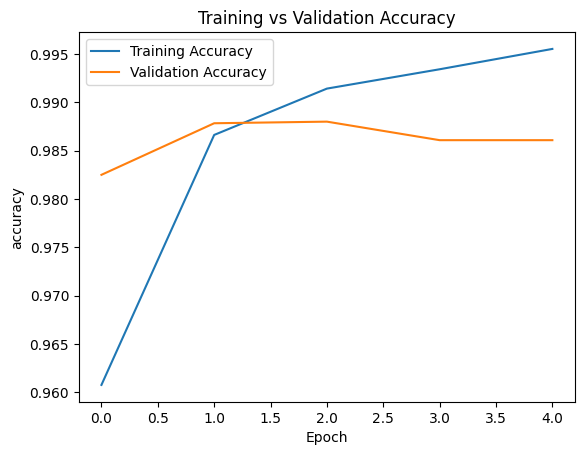

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(
    history.history["val_accuracy"], label="Validation Accuracy"
)
plt.title("Training vs Validation Accuracy")
plt.ylabel("accuracy")
plt.xlabel("Epoch")

plt.legend()
plt.show()

**[5.2]** Finally let's use our model to make predictions on the testing set by using the .predict() method.

##### **Task: Use the model to predict on the testing set**

Note:

- This method will use the `X_test` dataset

In [24]:
# Placeholder for student's code (1 line of code)
# Task: Use the model to predict on the testing set
sparse_pred_test = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


**[5.3]** Let's convert the sparse predictions into a class using [`.argmax()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.argmax.html) method from numpy.

##### **Task: Convert the sparse predictions to a single calss predictions**

In [25]:
# Placeholder for student's code (1 line of code)
# Task: Convert the sparse predictions to a single class predictions
pred_test = np.argmax(sparse_pred_test, axis=1)

**[5.4]** Now we can display the confusion matrix using the [`.confusion_matrix()`](https://www.tensorflow.org/api_docs/python/tf/math/confusion_matrix) method from TensorFlow.

In [26]:
cm = tf.math.confusion_matrix(pred_test, y_test, num_classes=10)
print(cm)

tf.Tensor(
[[ 963    0    0    0    0    1    1    0    0    0]
 [   0 1129    0    0    1    0    3    1    0    0]
 [   0    0 1007    0    0    0    0    0    1    0]
 [   0    1    9 1005    0    7    0    0    4    7]
 [   1    0    1    0  970    0    1    0    0    4]
 [   0    0    0    2    0  881    6    0    1    7]
 [  11    1    2    0    5    2  947    0    0    1]
 [   2    3   12    2    5    1    0 1026    2    9]
 [   1    1    1    1    0    0    0    1  966    2]
 [   2    0    0    0    1    0    0    0    0  979]], shape=(10, 10), dtype=int32)


In [27]:
cm = cm.numpy() #cm is a TensorFlow tensor and it is converted into a NumPy array.

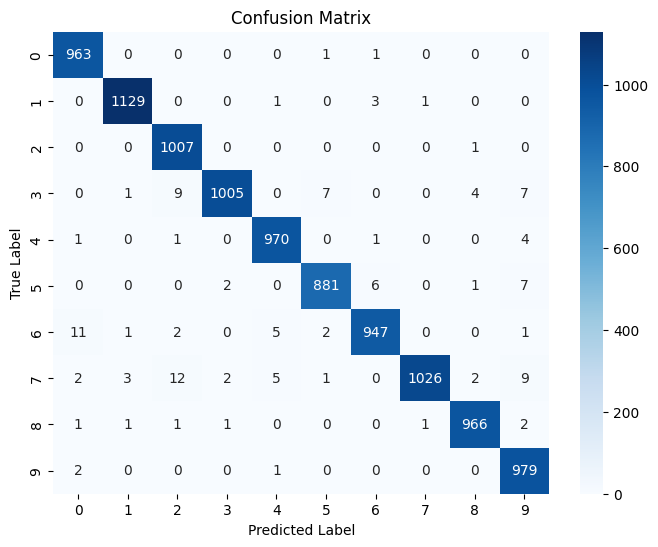

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,        # show numbers
    fmt='d',           # integer format
    cmap='Blues'       # color style
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

**Observation:** The confusion matrix indicates that the CNN performs strongly overall, with most correct predictions along the diagonal, giving an accuracy of around 95%+.However, it shows some confusion in distinguishing between similar digits, particularly 4 and 9.

In [29]:
#You can also display a classsifcation report which is a summary that shows how well your model performs for each class separately,
# instead of giving just one overall accuracy number.

from sklearn.metrics import classification_report

print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       980
           1       1.00      0.99      1.00      1135
           2       1.00      0.98      0.99      1032
           3       0.97      1.00      0.98      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.98      0.99      0.98       958
           7       0.97      1.00      0.98      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### **Congratulations!!! You just built your first CNN model in TensorFlow.**

# Submission
When you are ready to submit please go to `File` -> `Print` -> `Print PDF` and then upload and submit in the Campus Online.

Please save your file to GitHub via: `File` -> `Save a copy in GitHub`